In [ ]:
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import cdsapi
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon
import zipfile

# Downloading Data

In [135]:
beetle_cv = pd.read_csv('./data/beetle/lsu_processed.csv')
beetle_cv['Date'] = pd.to_datetime(beetle_cv['Date'])
beetle_cv

,Unnamed: 0,Plotno,Season,Date,Plot_Area,Proportion_of_Norway_spruce,Lon,Lat
0,0,3,0,2011-10-04,1963.0,100.0,19.212779,63.493099
1,1,4,2,2011-10-05,1963.0,100.0,18.562187,63.546142
2,2,4,1,2011-10-05,1963.0,100.0,18.562187,63.546142
3,3,4,1,2011-10-05,1963.0,100.0,18.562187,63.546142
4,4,4,1,2011-10-05,1963.0,100.0,18.562187,63.546142
...,...,...,...,...,...,...,...,...
2492,2492,867,0,2020-10-05,"1963,5",100.0,60.764318,3.441587
2493,2493,867,0,2020-10-05,"1963,5",100.0,60.764318,3.441587
2494,2494,867,0,2020-10-05,"1963,5",100.0,60.764318,3.441587
2495,2495,867,0,2020-10-05,"1963,5",100.0,60.764318,3.441587


In [85]:
date_windows = [(d - pd.Timedelta(days=30), d + pd.Timedelta(days=30)) for d in beetle_cv['Date'].unique()]
date_windows = sorted(date_windows, key=lambda x: x[0])
merged_windows = []

merged_windows = []
for start, end in date_windows:
    if not merged_windows:
        merged_windows.append((start, end))
    else:
        last_start, last_end = merged_windows[-1]
        if start <= last_end:  # Overlap detected
            # Merge the intervals
            merged_windows[-1] = (last_start, max(last_end, end))
        else:
            merged_windows.append((start, end))

del merged_windows[1]
merged_windows

[(Timestamp('2011-08-14 00:00:00'), Timestamp('2011-11-05 00:00:00')),
 (Timestamp('2012-08-19 00:00:00'), Timestamp('2012-11-07 00:00:00')),
 (Timestamp('2013-08-03 00:00:00'), Timestamp('2013-10-31 00:00:00')),
 (Timestamp('2014-08-07 00:00:00'), Timestamp('2014-11-07 00:00:00')),
 (Timestamp('2015-08-02 00:00:00'), Timestamp('2015-11-03 00:00:00')),
 (Timestamp('2016-07-31 00:00:00'), Timestamp('2016-10-29 00:00:00')),
 (Timestamp('2020-08-10 00:00:00'), Timestamp('2020-11-07 00:00:00'))]

In [136]:
max_year = int(beetle_cv['Date'].dt.year.max())
min_year = int(beetle_cv['Date'].dt.year.min())

min_lat = beetle_cv['Lat'].min()
max_lat = beetle_cv['Lat'].max()
min_lon = beetle_cv['Lon'].min()
max_lon = beetle_cv['Lon'].max()

bbox = [max_lat, min_lon, min_lat, max_lon]

In [87]:
bbox

[64.00967934397588, 14.729597665508258, 2.0406736312748155, 63.58549149632767]

In [88]:
eravar_to_var = {
    '2m_dewpoint_temperature' : 'dewtemp',
    '2m_temperature' : 't2m',
    'surface_solar_radiation_downwards' : 'solarrad',
    'total_precipitation' : 'totalprecip'
}

In [92]:
c = cdsapi.Client()

if True:
    for start, end in merged_windows:
        years = list({str(d.year) for d in pd.date_range(start, end)})
        months = list({f"{d.month:02d}" for d in pd.date_range(start, end)})
        days = list({f"{d.day:02d}" for d in pd.date_range(start, end)})

        for var in ["2m_dewpoint_temperature","2m_temperature","surface_solar_radiation_downwards","total_precipitation"]:

            filename = f"./data/weather/era5land_{eravar_to_var[var]}_{start.date()}_to_{end.date()}.zip"

            c.retrieve(
                'reanalysis-era5-land',
                {
                    "product_type": "reanalysis",
                    "variable": var,
                    "year": years,
                    "month": months,
                    "day": days,
                    'time': ['00:00', '06:00', '12:00', '18:00'],
                    "format": "netcdf",
                    'area': bbox
                },

                filename
            )

2025-12-06 09:21:50,472 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-12-06 09:21:50,651 INFO Request ID is e1803139-f96a-4327-b3ee-115e1ff616df
2025-12-06 09:21:50,725 INFO status has been updated to accepted
2025-12-06 09:21:59,173 INFO status has been updated to running
2025-12-06 09:22:04,297 INFO status has been updated to successful
2025-12-06 09:22:46,963 INFO Request ID is a3604c0e-9987-46f5-b411-c002a173bfba         
2025-12-06 09:22:47,018 INFO status has been updated to accepted
2025-12-06 09:23:00,602 INFO status has been updated to running
2025-12-06 09:24:41,254 INFO status has been updated to successful
2025-12-06 09:25:35,230 INFO Request ID is 1da967c7-0d52-4120-8c97-c8d92df53dc4          
2025-12-06 09:25:35,295 INFO status has been updated to accepted
2025-12-06 09:25:48,904 INFO status has been updated to running
2025-12-06 09:28:27,3

In [100]:
def unzip_to_nc(zip_path):
    dir_path = os.path.dirname(zip_path)
    zip_name = os.path.basename(zip_path)

    # Replace .zip with .nc and prefix with file_
    base = zip_name.replace(".zip", "")
    new_nc_name = f"file_{base}.nc"
    new_nc_path = os.path.join(dir_path, new_nc_name)

    with zipfile.ZipFile(zip_path, "r") as z:
        # find the .nc inside (even if in a subfolder)
        nc_members = [m for m in z.namelist() if m.endswith(".nc")]
        if len(nc_members) != 1:
            raise ValueError(f"Expected 1 nc file in {zip_path}, found: {nc_members}")

        member = nc_members[0]

        # write file to new location
        with z.open(member) as src, open(new_nc_path, "wb") as dst:
            dst.write(src.read())

    return new_nc_path

directory = "./data/weather"

for filename in os.listdir(directory):
    if filename.endswith(".zip"):
        zip_path = os.path.join(directory, filename)
        unzip_to_nc(zip_path)

## Combining weather data nc files to 1

In [101]:
nc_files = []
directory = './data/weather'

for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if not filename.startswith('file') or not filename.endswith('.nc'):
        continue
    file_path = os.path.join(directory, filename)
    nc_files.append(file_path)


# Optional: sort files (useful if filenames include dates)
nc_files.sort()

# Step 2: merge using xarray
ds = xr.open_mfdataset(
    nc_files,
    combine='nested',       # use nested because coordinates are not recognized
    concat_dim='valid_time',  # merge along valid_time dimension
    engine='netcdf4'
)

In [122]:
ds_daily = ds.sortby('valid_time').resample(valid_time='1D').mean()


## Combining with beetle

In [153]:
def extract_vars_from_nc_vectorized(df, ds, lat_col='Lat', lon_col='Lon', time_col='Date',
                                    ds_lat='latitude', ds_lon='longitude', ds_time='valid_time'):
    """
    Extract variables from xarray dataset `ds` for rows in `df` based on nearest
    latitude, longitude, and optionally time.
    """

    df_out = df.copy()

    # Ensure coordinates are numeric
    df_out[lat_col] = df_out[lat_col].astype(float)
    df_out[lon_col] = df_out[lon_col] % 360  # adjust to 0-360 if needed

    # Ensure datetime
    if time_col in df_out.columns:
        df_out[time_col] = pd.to_datetime(df_out[time_col])

    # Pull dataset coordinates
    ds_lats = ds[ds_lat].values
    ds_lons = ds[ds_lon].values

    # Find nearest indices
    lat_idx = np.abs(ds_lats[:, None] - df_out[lat_col].values).argmin(axis=0)
    lon_idx = np.abs(ds_lons[:, None] - df_out[lon_col].values).argmin(axis=0)

    # Check if dataset has time
    has_time = ds_time in ds.coords
    if has_time:
        ds_times = ds[ds_time].values
        df_times = df_out[time_col].values
        # nearest time index per row
        time_idx = np.array([np.abs(ds_times - t).argmin() for t in df_times])

    # Extract variables
    for var in ds.data_vars:
        var_vals = ds[var].values
        vals = np.empty(len(df_out))

        # Determine dimensionality
        dims = var_vals.ndim

        if has_time and dims == 3:
            for i, (t, la, lo) in enumerate(zip(time_idx, lat_idx, lon_idx)):
                vals[i] = var_vals[t, la, lo]
        elif not has_time and dims == 2:
            for i, (la, lo) in enumerate(zip(lat_idx, lon_idx)):
                vals[i] = var_vals[la, lo]
        elif has_time and dims == 2:  # some datasets have (time, lat) only
            for i, (t, la) in enumerate(zip(time_idx, lat_idx)):
                vals[i] = var_vals[t, la]
        elif dims == 1:  # e.g., only time or only lat
            for i, idx in enumerate(lat_idx):
                vals[i] = var_vals[idx]
        else:
            # fallback: flatten and pick nearest index
            flat_vals = var_vals.ravel()
            vals[:] = flat_vals[0]  # or np.nan
        df_out[var] = vals

    return df_out



In [143]:
df_weather = extract_vars_from_nc_vectorized(beetle_cv, ds_daily, lat_col='Lat', lon_col='Lon')


In [158]:
drought = xr.open_dataset('./data/spei01.nc')
df_final = extract_vars_from_nc_vectorized(
    df_weather,
    drought,
    lat_col='Lat',
    lon_col='Lon',
    time_col='Date',
    ds_lat='lat',
    ds_lon='lon',
    ds_time='time'
)

In [159]:
df_final.to_csv('./data/beetle/beetle_full.csv')

In [72]:
beetle_cv.to_csv('./data/beetle/beetle_full.csv', sep=',')

# Plotting

In [ ]:
var_nc_file = Dataset(path)

In [5]:
path = "./data/weather/spei01.nc"
var_nc_file = Dataset(path)
var_nc_file.variables.keys()

dict_keys(['lon', 'lat', 'time', 'spei', 'crs'])

In [ ]:


lats = var_nc_file.variables['latitude'][:]  
lons = var_nc_file.variables['longitude'][:]
lon2d, lat2d = np.meshgrid(lons, lats)
points = np.array([lon2d.ravel(), lat2d.ravel()]).T




dict_keys(['number', 'valid_time', 'latitude', 'longitude', 'expver', 't2m'])
(6, 721, 1440)


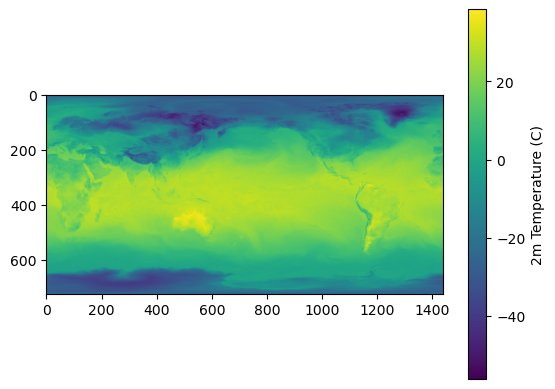

In [67]:
print(var_nc_file.variables.keys())

t2m = var_nc_file.variables["t2m"][:] - 273  # shape: (time, lat, lon)
print(t2m.shape)

plt.imshow(t2m[0, :, :], origin='upper')
plt.colorbar(label='2m Temperature (C)')
plt.show()

In [93]:
# Load country boundaries
world = gpd.read_file("./data/country/ne_110m_admin_0_sovereignty.shp")

# Select the country you want
country = world[world['ADMIN'] == 'Sweden']
poly = country.geometry.values[0]

mask = np.array([poly.contains(Point(xy)) for xy in points])
mask = mask.reshape(lon2d.shape)


In [88]:
t2m_masked = np.where(mask, t2m[0, :, :], np.nan)


minx, miny, maxx, maxy = country.total_bounds
lat_mask = (lats >= miny) & (lats <= maxy)
lon_mask = (lons >= minx) & (lons <= maxx)

lat2d_sub = lat2d[lat_mask, :][:, lon_mask]
lon2d_sub = lon2d[lat_mask, :][:, lon_mask]
t2m_sub = t2m_masked[lat_mask, :][:, lon_mask]


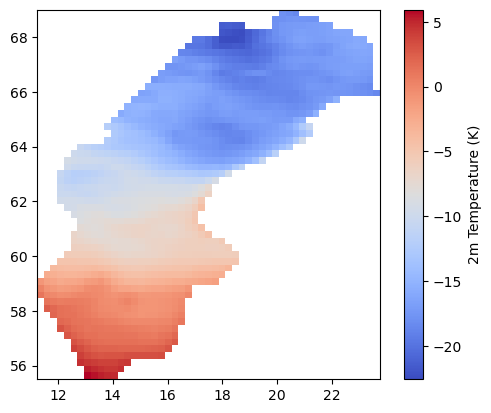

In [89]:

plt.imshow(
    t2m_sub,
    origin='upper',
    extent=[lon2d_sub.min(), lon2d_sub.max(), lat2d_sub.min(), lat2d_sub.max()],
    cmap='coolwarm'
)
plt.colorbar(label='2m Temperature (K)')
plt.show()

In [96]:
beetle_attacks = gpd.read_file("defid2.gpkg")

beetle_attacks = beetle_attacks[beetle_attacks['agents'] == 'Ips typographus']

/Users/jp/miniforge3/envs/fixathon/lib/python3.14/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'defid2.gpkg': 'exact_polygons' (default), 'exact_points', 'substitute_polygons', 'substitute_point'. Specify layer parameter to avoid this warning.
  result = read_func(


In [97]:
beetle_attacks

,event_id,geom_ids,survey_date,survey_date_precision,agents,hosts,symptoms,survey_method,trigger_primary,trigger_secondary,...,pattern_discoloration,pattern_mortality,pattern_dieback,severity_defoliation,severity_discoloration,severity_mortality,severity_dieback,is_affected,dataset_code,geometry
249,250,"250,251,252,253,254,255,256,257,258,259,260,26...",2006-10-15,+/- 15 days,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Aerial photointerpretation,Pest/Disease,None,...,high-contiguous,high-contiguous,high-contiguous,2.0,2.0,5.0,2.0,True,SK-001,"MULTIPOLYGON (((19.92358 49.13782, 19.92355 49..."
250,251,"712,713,714,715,716,717,718,719,720,721,722,72...",2007-10-15,+/- 15 days,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Aerial photointerpretation,Pest/Disease,None,...,high-contiguous,high-contiguous,high-contiguous,2.0,2.0,5.0,2.0,True,SK-001,"MULTIPOLYGON (((19.91983 49.14012, 19.91979 49..."
251,252,"1465,1466,1467,1468,1469,1470,1471,1472,1473,1...",2008-10-15,+/- 15 days,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Aerial photointerpretation,Pest/Disease,None,...,high-contiguous,high-contiguous,high-contiguous,2.0,2.0,5.0,2.0,True,SK-001,"MULTIPOLYGON (((19.89522 49.14161, 19.89528 49..."
252,253,"2507,2508,2509,2510,2511,2512,2513,2514,2515,2...",2009-10-15,+/- 15 days,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Aerial photointerpretation,Pest/Disease,None,...,high-contiguous,high-contiguous,high-contiguous,2.0,2.0,5.0,2.0,True,SK-001,"MULTIPOLYGON (((19.89952 49.14963, 19.89952 49..."
258,259,20034,2020-05-15,+/- 15 days,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Remote sensing classification,Pest/Disease,None,...,high-patchy,high-patchy,high-patchy,1.0,1.0,1.0,1.0,True,FI-001,"POLYGON ((24.92045 60.26097, 24.92303 60.2612,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612133,622021,644043,2021-09-30,11/2020-09/2021,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Remote sensing classification,None,None,...,None,None,None,2.0,2.0,5.0,2.0,True,CZ-004,"POLYGON ((17.31426 50.26539, 17.31437 50.26539..."
612134,622022,644044,2021-09-30,11/2020-09/2021,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Remote sensing classification,None,None,...,None,None,None,2.0,2.0,5.0,2.0,True,CZ-004,"POLYGON ((17.31484 50.26492, 17.31481 50.26506..."
612135,622023,644045,2021-09-30,11/2020-09/2021,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Remote sensing classification,None,None,...,None,None,None,2.0,2.0,5.0,2.0,True,CZ-004,"POLYGON ((17.31723 50.26455, 17.31723 50.2646,..."
612136,622024,644046,2021-09-30,11/2020-09/2021,Ips typographus,Picea abies,"Defoliation,Discolouration,Mortality,Dieback",Remote sensing classification,None,None,...,None,None,None,2.0,2.0,5.0,2.0,True,CZ-004,"POLYGON ((17.31739 50.26435, 17.31741 50.26431..."
